In [93]:
#SPY Daily Returns and Standard Deviation

In [94]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
df = yf.download("SPY", start="2000-01-01", end="2025-03-24", interval="1d")

clipped = df.drop(['Open', 'High', 'Low', 'Volume'], axis=1)

print(clipped.head())

closing_prices = df["Close"].values
closing_prices = closing_prices.flatten()
print(closing_prices)

daily_returns = np.diff(closing_prices) / closing_prices[:-1]
print(daily_returns)


daily_returns= daily_returns  * 100
returns_df = pd. DataFrame({"Daily Return (%)": daily_returns.round(2)}, index = df.index[1:])

returns_df["30 Day Standard Deviation (%)"] = returns_df["Daily Return (%)"].rolling(window=30).std()

print(returns_df)


[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker            SPY
Date                 
2000-01-03  92.414940
2000-01-04  88.800911
2000-01-05  88.959785
2000-01-06  87.530067
2000-01-07  92.613495
[ 92.41493988  88.80091095  88.95978546 ... 565.42907715 563.79400635
 563.97998047]
[-0.03910654  0.00178911 -0.01607151 ...  0.01089088 -0.00289173
  0.00032986]
            Daily Return (%)  30 Day Standard Deviation (%)
Date                                                       
2000-01-04             -3.91                            NaN
2000-01-05              0.18                            NaN
2000-01-06             -1.61                            NaN
2000-01-07              5.81                            NaN
2000-01-10              0.34                            NaN
...                      ...                            ...
2025-03-17              0.77                       1.100237
2025-03-18             -1.08                       1.108901
2025-03-19              1.09                       1.122891


In [95]:
#TLT Daily Returns and Standard Deviation

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
df2 = yf.download("TLT", start="2000-01-01", end="2025-03-24", interval="1d")

clipped2 = df2.drop(['Open', 'High', 'Low', 'Volume'], axis=1)

print(clipped2.head())

closing_prices1 = df2["Close"].values
closing_prices2 = closing_prices1.flatten()
print(closing_prices2)

daily_returns1 = np.diff(closing_prices2) / closing_prices2[:-1]
print(daily_returns1)


daily_returns1= daily_returns1  * 100
returns_df2 = pd. DataFrame({"Daily Return (%)": daily_returns1.round(2)}, index = df2.index[1:])

returns_df2["30 Day Standard Deviation (%)"] = returns_df2["Daily Return (%)"].rolling(window=30).std()

print(returns_df2)

[*********************100%***********************]  1 of 1 completed

Price           Close
Ticker            TLT
Date                 
2002-07-30  37.887405
2002-07-31  38.356796
2002-08-01  38.575237
2002-08-02  38.970299
2002-08-05  39.142254
[37.8874054  38.35679626 38.57523727 ... 90.85346222 90.91324615
 90.37518311]
[ 0.0123891   0.00569498  0.01024132 ...  0.00518133  0.00065803
 -0.00591842]
            Daily Return (%)  30 Day Standard Deviation (%)
Date                                                       
2002-07-31              1.24                            NaN
2002-08-01              0.57                            NaN
2002-08-02              1.02                            NaN
2002-08-05              0.44                            NaN
2002-08-06             -0.85                            NaN
...                      ...                            ...
2025-03-17              0.50                       0.890718
2025-03-18              0.10                       0.881485
2025-03-19              0.52                       0.883967
2025-0

In [97]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

sm.qqplot()

TypeError: qqplot() missing 1 required positional argument: 'data'

In [98]:
import yfinance as yf
import pandas as pd

# Define the tickers
tickers = ['SPY', 'TLT']

# Download historical closing prices for the past 10 years
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']

# Optional: Rename columns to make it clear
data.columns = ['SPY Close', 'TLT Close']

# Display the first few rows
print(data.head())

[*********************100%***********************]  2 of 2 completed

             SPY Close   TLT Close
Date                              
2015-01-02  172.075226   97.964409
2015-01-05  168.967575   99.503227
2015-01-06  167.376129  101.296028
2015-01-07  169.461823  101.096008
2015-01-08  172.468918   99.757126


[*********************100%***********************]  2 of 2 completed


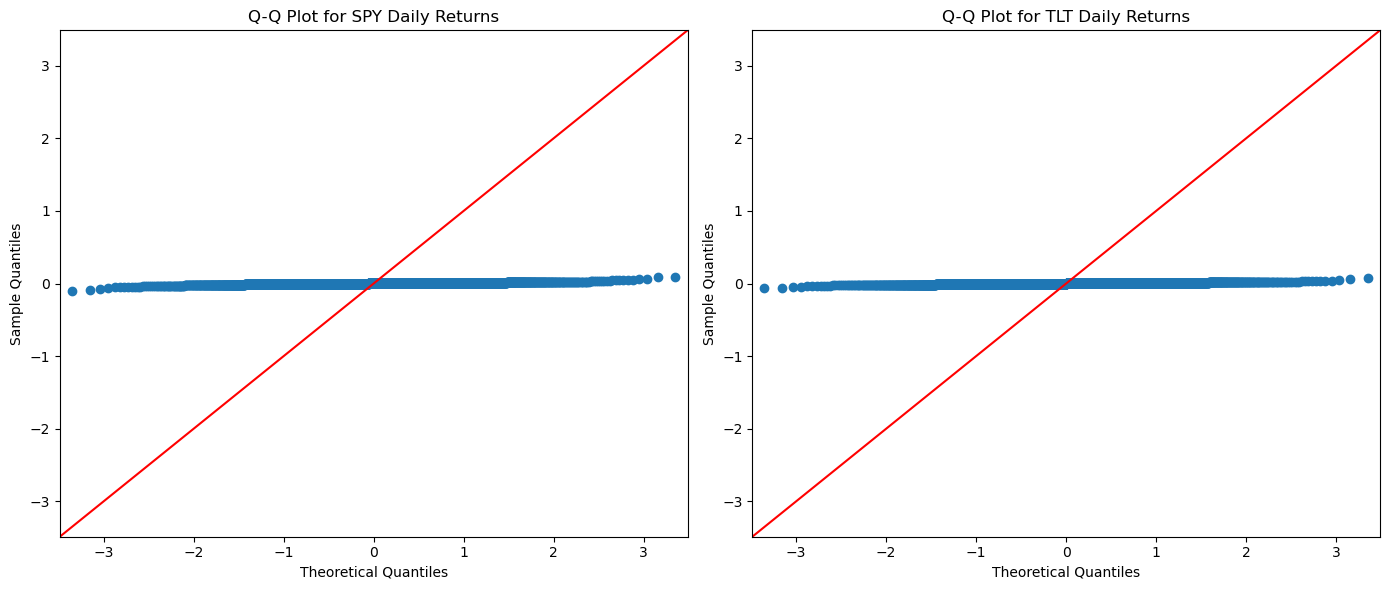

In [99]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Download the data
tickers = ['SPY', 'TLT']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']
data.columns = ['SPY Close', 'TLT Close']

# Calculate **daily returns** instead of prices
returns = data.pct_change().dropna()

# Set up two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q plot for SPY
sm.qqplot(returns['SPY Close'], stats.norm, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot for SPY Daily Returns')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')

# Q-Q plot for TLT
sm.qqplot(returns['TLT Close'], stats.norm, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot for TLT Daily Returns')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

# Adjust layout
plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed


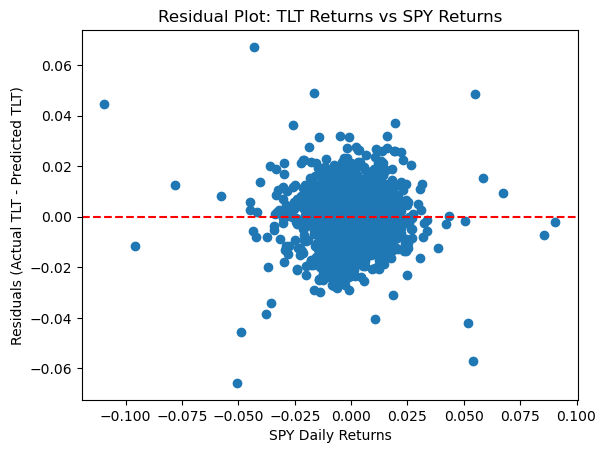

In [139]:
# Download SPY and TLT data
tickers = ['SPY', 'TLT']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['SPY', 'TLT']

# Let's use daily returns
returns = data.pct_change().dropna()

# Now x = SPY returns, y = TLT returns
x = returns[['SPY']].values  # needs to be 2D array
y = returns['TLT'].values    # target values

# Fit model
model = LinearRegression()
model.fit(x, y)

# Predict and calculate residuals
y_predicted = model.predict(x)
residuals = y - y_predicted

# Plot residuals
plt.scatter(x, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: TLT Returns vs SPY Returns')
plt.xlabel('SPY Daily Returns')
plt.ylabel('Residuals (Actual TLT - Predicted TLT)')
plt.show()

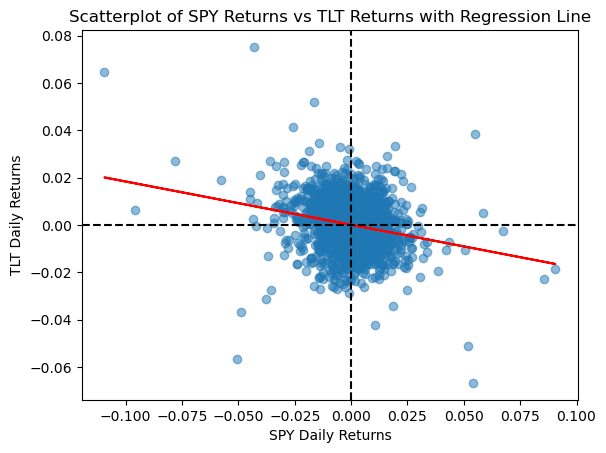

Correlation between SPY and TLT returns: -0.2101545328044699


In [119]:
from sklearn.linear_model import LinearRegression

# x = SPY returns, y = TLT returns
x = returns[['SPY']].values
y = returns['TLT'].values

model = LinearRegression()
model.fit(x, y)

# Predict y values for plotting the line
y_pred = model.predict(x)

# Scatter plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color='red')  # Add the regression line
plt.title('Scatterplot of SPY Returns vs TLT Returns with Regression Line')
plt.xlabel('SPY Daily Returns')
plt.ylabel('TLT Daily Returns')
plt.axhline(y=0, color='black', linestyle='--')  # optional, center line
plt.axvline(x=0, color='black', linestyle='--')  # optional, center line
plt.show()
correlation = returns['SPY'].corr(returns['TLT'])
print("Correlation between SPY and TLT returns:", correlation)

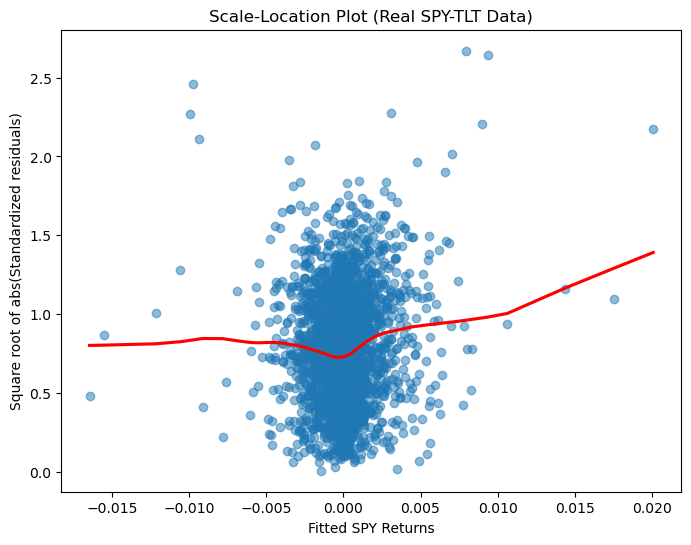

In [120]:
import seaborn as sns
x = returns[['SPY']].values
y = returns['TLT'].values

# Fit linear regression model
model = LinearRegression()
model.fit(x, y)

# Get fitted values and residuals
fitted_values = model.predict(x)
residuals = y - fitted_values

# Standardize residuals
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

# Plot Scale-Location Plot
plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.5)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(std_residuals)), scatter=False, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted SPY Returns')
plt.ylabel('Square root of abs(Standardized residuals)')
plt.title('Scale-Location Plot (Real SPY-TLT Data)')
plt.show()

In [121]:
# Download SPY and TLT data
tickers = ['SPY', 'TLT']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['SPY', 'TLT']

# Calculate daily returns
returns = data.pct_change().dropna()

# Set portfolio weights: 60% SPY, 40% TLT
w1 = 0.6  # SPY weight
w2 = 0.4  # TLT weight

# Calculate daily standard deviations
std_spy = returns['SPY'].std()
std_tlt = returns['TLT'].std()

print("Daily Standard Deviation of SPY:", std_spy)
print("Daily Standard Deviation of TLT:", std_tlt)
# Calculate individual variances
var1 = returns['SPY'].var()
var2 = returns['TLT'].var()

# Calculate covariance between SPY and TLT
cov12 = returns['SPY'].cov(returns['TLT'])

# Calculate portfolio variance
portfolio_variance = (w1**2) * var1 + (w2**2) * var2 + (2 * w1 * w2 * cov12)

# Take square root for portfolio standard deviation
portfolio_std_dev = np.sqrt(portfolio_variance)


print("Covariance between SPY and TLT:", cov12)
print("Portfolio Variance (60/40 weights):", portfolio_variance)
print("Portfolio Standard Deviation (60/40 weights):", portfolio_std_dev)

[*********************100%***********************]  2 of 2 completed

Daily Standard Deviation of SPY: 0.011099048582544607
Daily Standard Deviation of TLT: 0.009647908774161515
Covariance between SPY and TLT: -2.2503895498674913e-05
Portfolio Variance (60/40 weights): 4.843926975252963e-05
Portfolio Standard Deviation (60/40 weights): 0.006959832595151239


In [122]:
correlation = returns['SPY'].corr(returns['TLT'])

print("Correlation coefficient between SPY and TLT:", correlation)

Correlation coefficient between SPY and TLT: -0.2101545328044699


In [123]:
# SPY and TLT variances (from earlier)
var_SPY = 0.00012318878842633674
var_TLT = 9.308236027969338e-05

# Calculate individual volatilities
std_SPY = np.sqrt(var_SPY)
std_TLT = np.sqrt(var_TLT)

print("Daily Volatility (Standard Deviation) of SPY:", std_SPY)
print("Daily Volatility (Standard Deviation) of TLT:", std_TLT)

Daily Volatility (Standard Deviation) of SPY: 0.011099044482582126
Daily Volatility (Standard Deviation) of TLT: 0.009647919997579446


[*********************100%***********************]  2 of 2 completed


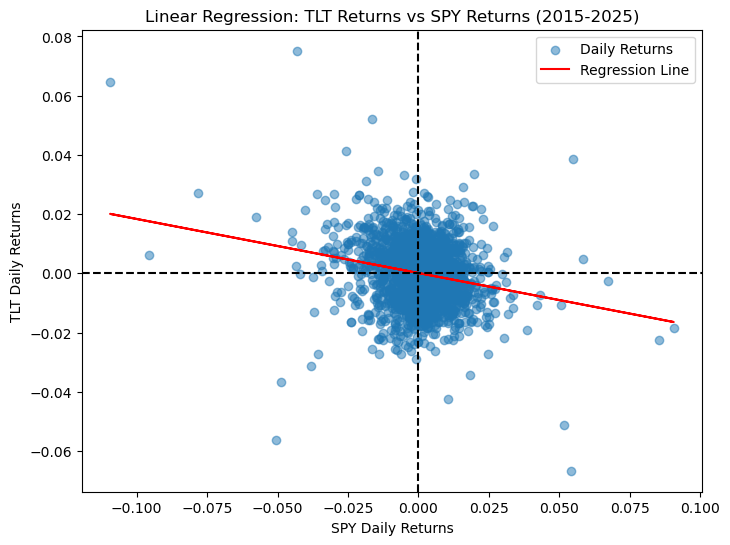

Correlation coefficient (r): -0.2101545328044699
Coefficient of determination (r^2): 0.04416492765826496
Daily Standard Deviation of SPY: 0.011099048582544607
Daily Standard Deviation of TLT: 0.009647908774161515
Portfolio Standard Deviation: 0.006959832595151239


In [124]:
# Step 1: Download SPY and TLT data
tickers = ['SPY', 'TLT']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']

# Step 2: Flatten and rename columns
data.columns = ['SPY', 'TLT']

# Step 3: Calculate daily returns
returns = data.pct_change().dropna()

# Step 4: Set up X (SPY returns) and y (TLT returns)
X = returns[['SPY']].values  # must be 2D
y = returns['TLT'].values    # target

# Step 5: Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Step 6: Predict fitted values
y_pred = model.predict(X)

# Step 7: Scatter plot with regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label="Daily Returns")
plt.plot(X, y_pred, color='red', label="Regression Line")
plt.axhline(y=0, color='black', linestyle='--')  # horizontal zero line
plt.axvline(x=0, color='black', linestyle='--')  # vertical zero line
plt.xlabel('SPY Daily Returns')
plt.ylabel('TLT Daily Returns')
plt.title('Linear Regression: TLT Returns vs SPY Returns (2015-2025)')
plt.legend()
plt.show()

# Step 7: Calculate r (correlation coefficient) for SPY and TLT
r = returns['SPY'].corr(returns['TLT'])
print("Correlation coefficient (r):", r)

# Step 8: Calculate r^2 (coefficient of determination) for SPY and TLT
r_squared = model.score(X, y)
print("Coefficient of determination (r^2):", r_squared)


var_SPY = returns['SPY'].var()
var_TLT = returns['TLT'].var()

# Calculate daily standard deviations
std_spy = returns['SPY'].std()
std_tlt = returns['TLT'].std()

print("Daily Standard Deviation of SPY:", std_spy)
print("Daily Standard Deviation of TLT:", std_tlt)
# Covariance
cov_SPY_TLT = returns['SPY'].cov(returns['TLT'])


# Weights
w1 = 0.6
w2 = 0.4

# Portfolio Variance
portfolio_variance = (w1**2) * var_SPY + (w2**2) * var_TLT + (2 * w1 * w2 * cov_SPY_TLT)


# Portfolio Standard Deviation
portfolio_std_dev = np.sqrt(portfolio_variance)
print("Portfolio Standard Deviation:", portfolio_std_dev)

In [125]:
# Step 1: Download all 4 tickers
tickers = ['MSFT', 'AAPL', 'SPY', 'TLT']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']

# Step 2: Calculate daily returns
returns = data.pct_change().dropna()

# Step 3: Individual betas
beta_spy = returns['SPY'].cov(returns['SPY']) / returns['SPY'].var()  # will always equal 1
beta_tlt = returns['TLT'].cov(returns['SPY']) / returns['SPY'].var()

# Step 4: Portfolio beta (60% SPY, 40% TLT)
w1 = 0.6  # SPY
w2 = 0.4  # TLT
beta_portfolio = w1 * beta_spy + w2 * beta_tlt

# Step 5: Print results
print("Beta of SPY (should be 1):", beta_spy)
print("Beta of TLT relative to SPY:", beta_tlt)
print("Portfolio Beta (SPY/TLT 60/40):", beta_portfolio)

[*********************100%***********************]  4 of 4 completed

Beta of SPY (should be 1): 0.9999999999999991
Beta of TLT relative to SPY: -0.18267797873799488
Portfolio Beta (SPY/TLT 60/40): 0.5269288085048015


In [126]:
tickers = ['MSFT', 'AAPL']

# Download the historical closing price data
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']

# Optional: Rename columns for clarity
data.columns = ['Microsoft Close', 'Apple Close']

# Display the first few rows
print(data.head())

[*********************100%***********************]  2 of 2 completed

            Microsoft Close  Apple Close
Date                                    
2015-01-02        24.320431    40.072121
2015-01-05        23.635284    39.703636
2015-01-06        23.637510    39.120892
2015-01-07        23.968960    39.617928
2015-01-08        24.889900    40.783417


[*********************100%***********************]  2 of 2 completed


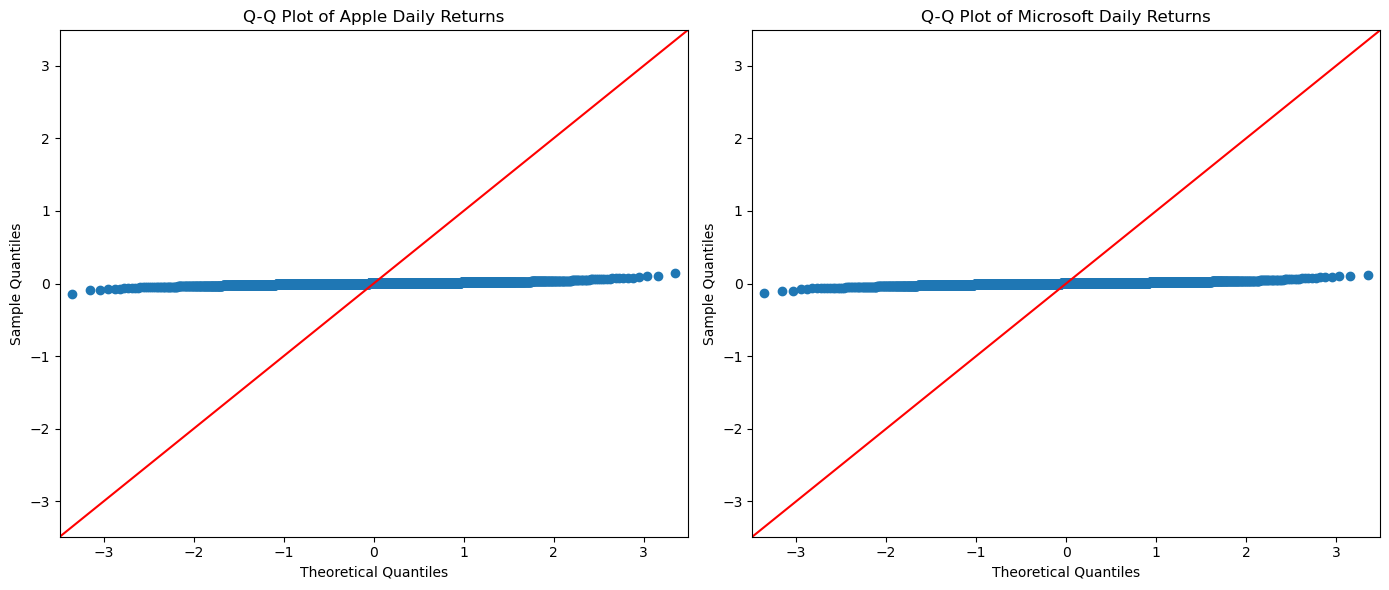

In [127]:
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']
data.columns = ['Microsoft Close', 'Apple Close']

# Calculate daily returns
returns = data.pct_change().dropna()

# Create two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Q-Q plot for Apple
sm.qqplot(returns['Apple Close'], stats.norm, line='45', ax=axes[0])
axes[0].set_title('Q-Q Plot of Apple Daily Returns')
axes[0].set_xlabel('Theoretical Quantiles')
axes[0].set_ylabel('Sample Quantiles')

# Q-Q plot for Microsoft
sm.qqplot(returns['Microsoft Close'], stats.norm, line='45', ax=axes[1])
axes[1].set_title('Q-Q Plot of Microsoft Daily Returns')
axes[1].set_xlabel('Theoretical Quantiles')
axes[1].set_ylabel('Sample Quantiles')

plt.tight_layout()
plt.show()


[*********************100%***********************]  2 of 2 completed


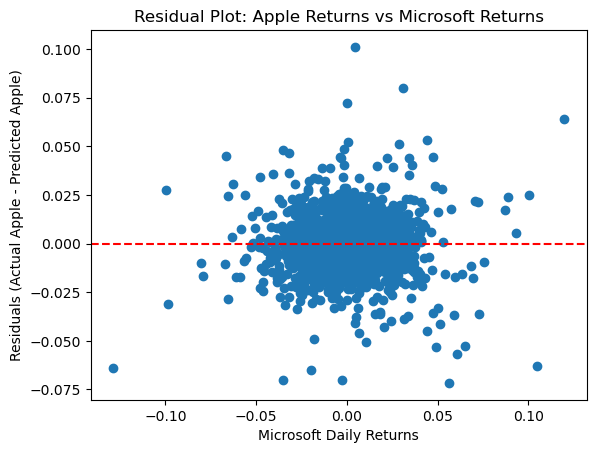

In [128]:

# Download Microsoft and Apple data
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['MSFT', 'AAPL']

# Let's use daily returns
returns = data.pct_change().dropna()

# Now x = Microsoft returns, y = Apple returns
x = returns[['MSFT']].values  # needs to be 2D array
y = returns['AAPL'].values    # target values

# Fit model
model = LinearRegression()
model.fit(x, y)

# Predict and calculate residuals
y_predicted = model.predict(x)
residuals = y - y_predicted

# Plot residuals
plt.scatter(x, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot: Apple Returns vs Microsoft Returns')
plt.xlabel('Microsoft Daily Returns')
plt.ylabel('Residuals (Actual Apple - Predicted Apple)')
plt.show()


[*********************100%***********************]  2 of 2 completed


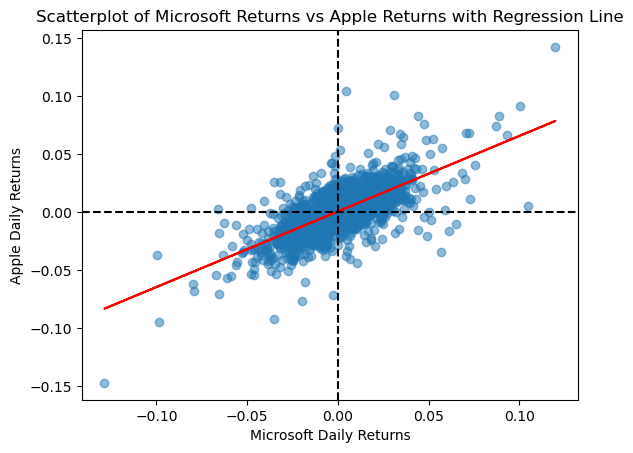

Correlation between Microsoft and Apple returns: 0.6828518530152013


In [129]:
# Download Microsoft and Apple data
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['MSFT', 'AAPL']

# Calculate daily returns
returns = data.pct_change().dropna()

# x = Microsoft returns, y = Apple returns
x = returns[['MSFT']].values  # needs to be 2D array
y = returns['AAPL'].values    # target values

# Fit model
model = LinearRegression()
model.fit(x, y)

# Predict y values for plotting the regression line
y_pred = model.predict(x)

# Scatter plot
plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_pred, color='red')  # Add the regression line
plt.title('Scatterplot of Microsoft Returns vs Apple Returns with Regression Line')
plt.xlabel('Microsoft Daily Returns')
plt.ylabel('Apple Daily Returns')
plt.axhline(y=0, color='black', linestyle='--')  # optional, center line
plt.axvline(x=0, color='black', linestyle='--')  # optional, center line
plt.show()

# Calculate and print correlation
correlation = returns['MSFT'].corr(returns['AAPL'])
print("Correlation between Microsoft and Apple returns:", correlation)

[*********************100%***********************]  2 of 2 completed


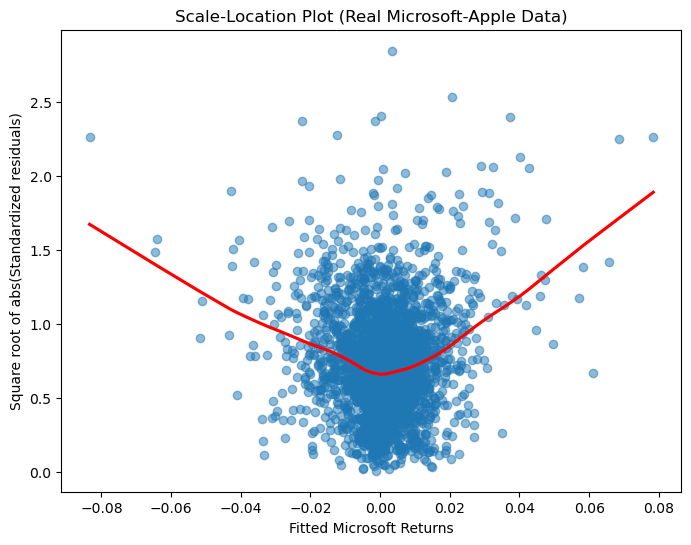

In [130]:
import seaborn as sns
# Download Microsoft and Apple data
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['MSFT', 'AAPL']

# Calculate daily returns
returns = data.pct_change().dropna()

# Set up x and y
x = returns[['MSFT']].values  # Microsoft returns
y = returns['AAPL'].values    # Apple returns

# Fit linear regression model
model = LinearRegression()
model.fit(x, y)

# Get fitted values and residuals
fitted_values = model.predict(x)
residuals = y - fitted_values

# Standardize residuals
std_residuals = (residuals - np.mean(residuals)) / np.std(residuals)

# Create Scale-Location Plot
plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, np.sqrt(np.abs(std_residuals)), alpha=0.5)
sns.regplot(x=fitted_values, y=np.sqrt(np.abs(std_residuals)), scatter=False, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted Microsoft Returns')
plt.ylabel('Square root of abs(Standardized residuals)')
plt.title('Scale-Location Plot (Real Microsoft-Apple Data)')
plt.show()

In [131]:
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']
data.columns = ['MSFT', 'AAPL']

# Calculate daily returns
returns = data.pct_change().dropna()

# Fixed portfolio weights: 60% Microsoft, 40% Apple
w1 = 0.6  # Microsoft
w2 = 0.4  # Apple

# Calculate individual variances
var1 = returns['MSFT'].var()
var2 = returns['AAPL'].var()

# Calculate covariance between Microsoft and Apple
cov12 = returns['MSFT'].cov(returns['AAPL'])

# Portfolio variance formula
portfolio_variance = (w1**2) * var1 + (w2**2) * var2 + (2 * w1 * w2 * cov12)

# Take square root for portfolio standard deviation
portfolio_std_dev = np.sqrt(portfolio_variance)

# Print results
print("Variance of Microsoft:", var1)
print("Variance of Apple:", var2)
print("Covariance between Microsoft and Apple:", cov12)
print("Portfolio Variance (60/40 weights):", portfolio_variance)
print("Portfolio Standard Deviation (60/40 weights):", portfolio_std_dev)



[*********************100%***********************]  2 of 2 completed

Variance of Microsoft: 0.0003214569959733324
Variance of Apple: 0.0002922722945304349
Covariance between Microsoft and Apple: 0.0002093060384007446
Portfolio Variance (60/40 weights): 0.0002629549841076267
Portfolio Standard Deviation (60/40 weights): 0.016215886781413672


In [132]:
# Step 1: Download Microsoft and Apple data
tickers = ['MSFT', 'AAPL']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01")['Close']

# Step 2: Confirm column names
print("Columns after download:", data.columns)

# Step 3: Calculate daily returns
returns = data.pct_change().dropna()

# Step 4: Calculate correlation coefficient
correlation_msft_aapl = returns['MSFT'].corr(returns['AAPL'])

# Step 5: Print result
print("Correlation coefficient between Microsoft and Apple daily returns:", correlation_msft_aapl)

[*********************100%***********************]  2 of 2 completed

Columns after download: Index(['AAPL', 'MSFT'], dtype='object', name='Ticker')
Correlation coefficient between Microsoft and Apple daily returns: 0.6828518530152012


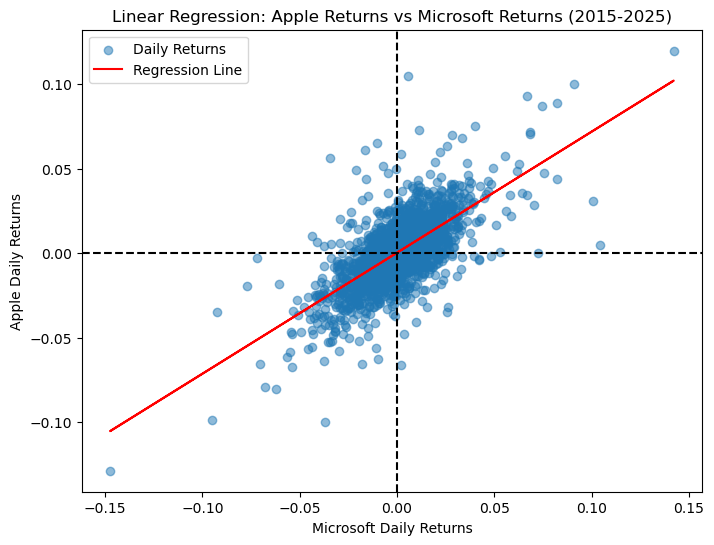

In [133]:
# Step 2: Calculate daily returns
returns = data.pct_change().dropna()

# Step 3: Set up X (Microsoft returns) and y (Apple returns)
X = returns[['MSFT']].values  # Predictor: Microsoft (must be 2D array)
y = returns['AAPL'].values    # Target: Apple (1D array)

# Step 4: Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Step 5: Predict fitted values for regression line
y_pred = model.predict(X)

# Step 6: Scatter plot and regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label="Daily Returns")
plt.plot(X, y_pred, color='red', label="Regression Line")
plt.axhline(y=0, color='black', linestyle='--')  # optional center line
plt.axvline(x=0, color='black', linestyle='--')  # optional center line
plt.xlabel('Microsoft Daily Returns')
plt.ylabel('Apple Daily Returns')
plt.title('Linear Regression: Apple Returns vs Microsoft Returns (2015-2025)')
plt.legend()
plt.show()


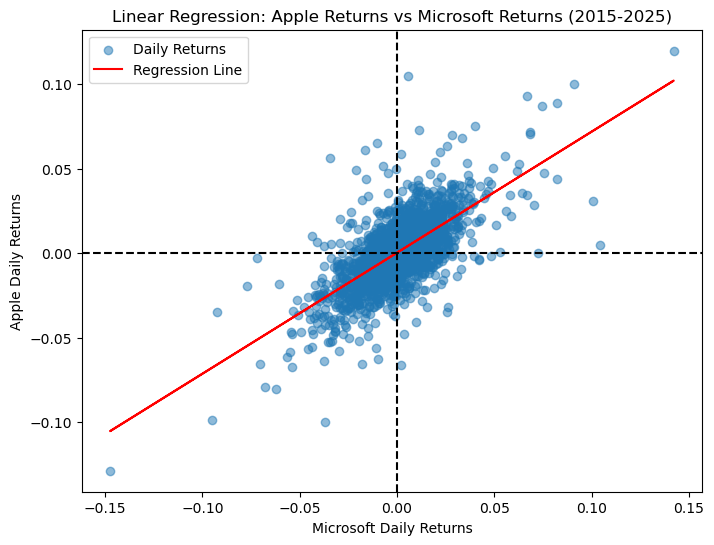

Correlation coefficient (r): 0.6828518530152012
Coefficient of determination (r^2): 0.46628665316629403
Portfolio Standard Deviation (MSFT/AAPL): 0.016034900804777284
Daily Standard Deviation of Microsoft (MSFT): 0.017095973050120162
Daily Standard Deviation of Apple (AAPL): 0.017929221845170314


In [134]:
# Step 2: Calculate daily returns
returns = data.pct_change().dropna()

# FIX column names if needed
returns.columns = [col.replace(' Close', '') for col in returns.columns]

# Step 3: Set up X (Microsoft returns) and y (Apple returns)
X = returns[['MSFT']].values  # Predictor: Microsoft (must be 2D array)
y = returns['AAPL'].values    # Target: Apple (1D array)

# Step 4: Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Step 5: Predict fitted values for regression line
y_pred = model.predict(X)

# Step 6: Scatter plot and regression line
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.5, label="Daily Returns")
plt.plot(X, y_pred, color='red', label="Regression Line")
plt.axhline(y=0, color='black', linestyle='--')  # optional center line
plt.axvline(x=0, color='black', linestyle='--')  # optional center line
plt.xlabel('Microsoft Daily Returns')
plt.ylabel('Apple Daily Returns')
plt.title('Linear Regression: Apple Returns vs Microsoft Returns (2015-2025)')
plt.legend()
plt.show()

# Step 7: Calculate r (correlation coefficient)
r = returns['MSFT'].corr(returns['AAPL'])
print("Correlation coefficient (r):", r)

# Step 8: Calculate r^2 (coefficient of determination)
r_squared = model.score(X, y)
print("Coefficient of determination (r^2):", r_squared)

# Step 2: Individual variances
var_MSFT = returns['MSFT'].var()
var_AAPL = returns['AAPL'].var()



# Step 3: Covariance
cov_MSFT_AAPL = returns['MSFT'].cov(returns['AAPL'])


# Step 4: Portfolio variance
w1 = 0.6
w2 = 0.4
portfolio_variance = (w1**2) * var_MSFT + (w2**2) * var_AAPL + (2 * w1 * w2 * cov_MSFT_AAPL)


# Step 5: Portfolio standard deviation
portfolio_std_dev = np.sqrt(portfolio_variance)
print("Portfolio Standard Deviation (MSFT/AAPL):", portfolio_std_dev)

# Daily standard deviations
std_msft = returns['MSFT'].std()
std_aapl = returns['AAPL'].std()

print("Daily Standard Deviation of Microsoft (MSFT):", std_msft)
print("Daily Standard Deviation of Apple (AAPL):", std_aapl)

In [115]:
import yfinance as yf
import numpy as np

# Download MSFT, AAPL, SPY
tickers = ['MSFT', 'AAPL', 'SPY']
data = yf.download(tickers, start="2015-01-01", end="2025-01-01", interval="1d")['Close']

# Calculate returns
returns = data.pct_change().dropna()

# Calculate individual betas
beta_msft = returns['MSFT'].cov(returns['SPY']) / returns['SPY'].var()
beta_aapl = returns['AAPL'].cov(returns['SPY']) / returns['SPY'].var()

print("Beta of Microsoft relative to SPY:", beta_msft)
print("Beta of Apple relative to SPY:", beta_aapl)

# Portfolio beta (60% MSFT, 40% AAPL)
w1 = 0.6
w2 = 0.4
beta_portfolio = w1 * beta_msft + w2 * beta_aapl

print("Portfolio Beta (MSFT/AAPL 60/40):", beta_portfolio)

[*********************100%***********************]  3 of 3 completed

Beta of Microsoft relative to SPY: 1.2254179745315363
Beta of Apple relative to SPY: 1.2072851817781127
Portfolio Beta (MSFT/AAPL 60/40): 1.218164857430167


In [135]:
import yfinance as yf
import numpy as np
import pandas as pd

# Download daily adjusted closing prices
tickers = ['SPY', 'TLT']
data = yf.download(tickers, start='2015-01-01', end='2025-01-01')['Adj Close']

# Calculate daily returns
daily_returns = data.pct_change().dropna()

# Portfolio weights (50% SPY, 50% TLT)
weights = np.array([0.5, 0.5])

# Portfolio daily returns
portfolio_returns = daily_returns.dot(weights)

# Annualized return and standard deviation
annual_return = np.mean(portfolio_returns) * 252
annual_std = np.std(portfolio_returns) * np.sqrt(252)

# Risk-free rate (2%)
risk_free_rate = 0.02

# Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annual_std

print(f"Annual Return: {annual_return:.4f}")
print(f"Annual Volatility: {annual_std:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

[*********************100%***********************]  2 of 2 completed


KeyError: 'Adj Close'

In [138]:
import yfinance as yf
import numpy as np
import pandas as pd

# Download price data
tickers = ['AAPL', 'MSFT']
data = yf.download(tickers, start='2015-01-01', end='2025-01-01')

# Check if multi-index columns are present
if isinstance(data.columns, pd.MultiIndex):
    adj_close = data['Adj Close']
else:
    adj_close = data[['Adj Close']]

# Calculate daily returns
daily_returns = adj_close.pct_change().dropna()

# Portfolio weights (50% AAPL, 50% MSFT)
weights = np.array([0.5, 0.5])

# Portfolio daily returns
portfolio_returns = daily_returns.dot(weights)

# Annualized return and standard deviation
annual_return = np.mean(portfolio_returns) * 252
annual_std = np.std(portfolio_returns) * np.sqrt(252)

# Risk-free rate (2%)
risk_free_rate = 0.02

# Sharpe Ratio
sharpe_ratio = (annual_return - risk_free_rate) / annual_std

print(f"Annual Return: {annual_return:.4f}")
print(f"Annual Volatility: {annual_std:.4f}")
print(f"Sharpe Ratio: {sharpe_ratio:.4f}")

[*********************100%***********************]  2 of 2 completed


KeyError: 'Adj Close'